In [101]:
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegFileWriter
from matplotlib.gridspec import GridSpec
import numpy as np
import scipy as sp
import time

In [102]:
def timer_dec(base_func):
    def extended_func(*args, **kwargs):
        start = time.time()
        result = base_func(*args, **kwargs)
        end = time.time()
        enlapsed_s = end - start
        print(f"enlapsed_us of {base_func.__name__}: {enlapsed_s:.2f}s ")
        return result

    return extended_func

In [103]:
class Grid:
    def __init__(self,Nx,L):
        self.Nx = Nx 
        self.L = L
        self.dx  = L / Nx 

        self.x = np.linspace(-L/2,L/2,Nx,endpoint=False)
        self.k = 2.0 * np.pi * np.fft.fftfreq(Nx,d = self.dx)


In [104]:
class Potential:
    @staticmethod
    def finite_barrier(x,x0,x1,height):
        V = np.zeros_like(x)
        mask = (x >= x0) & (x <= x1)
        V[mask] = height
        return V

In [105]:
class WaveFunction:
    def __init__(self,grid):
        self.grid = grid
        
    def gaussian(self,x0,k0,sigma):
       psi =  np.exp(1j * k0 * self.grid.x)* np.exp( - (self.grid.x - x0)**2 / (2 * sigma**2) )
       return self.normalize(psi)

    def normalize(self,psi):
        dx = self.grid.dx
        return psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)
        


In [106]:
class TDSESolver:
    def __init__(self,grid,dt,V,m=1.0,hbar=1.0):
        self.grid = grid
        self.dt = dt
        self.V = V
        self.m = m
        self.hbar = hbar

        self.T_k = np.exp(-1j * (hbar * grid.k**2 / (2 *m ))* dt)
        self.V_half = np.exp(-1j * V * dt / (2 * hbar))

    def step(self,psi):
        # 1st half step
        psi = self.V_half * psi

        # Fourier Transform from x t p

        psi_k = np.fft.fft(psi)

        # Apply Kinetic engery operator
        psi_k *= self.T_k

        # Inverse Fourier Transfrom from p to x
        psi = np.fft.ifft(psi_k) 

        # 2nd Half step
        psi  =  self.V_half * psi

        return psi
    @timer_dec
    def run(self,psi0,Nt):

        psi = psi0.copy()
        res = []

        for _ in range(Nt):
            psi = self.step(psi)
            psi /= np.sqrt(np.sum(np.abs(psi)**2) * self.grid.dx)
            res.append(psi)

        return np.array(res)
    
        

In [107]:
class Observerables:
    def __init__(self,grid,potential):
        self.x = grid.x
        self.dx = grid.dx
        self.V = potential

    def norm(self, psi):
        return np.sum(np.abs(psi)**2) * self.dx

    def transmission_reflection(self,psi,barrier_left,barrier_right):
        prob_density = np.abs(psi)**2

        left = self.x < barrier_left
        right = self.x > barrier_right

        R = np.sum(prob_density[left]) * self.dx
        T = np.sum(prob_density[right]) * self.dx
        return T, R

    def potential_energy(self,psi):
        return np.sum(np.abs(psi)**2 * self.V) * self.dx

     
    def kinetic_energy(self, psi, grid, hbar=1.0, m=1.0):
        psi_k = np.fft.fft(psi) * grid.dx 
     
        energy_k = (hbar**2 * grid.k**2) / (2*m)
        dk = 2 * np.pi / grid.L
        return np.sum(np.abs(psi_k)**2 * energy_k) * dk / (2*np.pi)

    @timer_dec
    def track_all(self,res,grid,barrier_left,barrier_right,hbar):
        T_list, R_list = [] , []
        KE_list, PE_list  = [] , []
        Norm_list = []
        for psi in res:

            T,R = self.transmission_reflection(psi,barrier_left,barrier_right)
            KE = self.kinetic_energy(psi,grid)
            PE = self.potential_energy(psi)
            Norm = np.sum(np.abs(psi)**2) * grid.dx

            T_list.append(T)
            R_list.append(R)
            PE_list.append(PE)
            KE_list.append(KE)
            Norm_list.append(Norm)
        return T_list, R_list, KE_list, PE_list, Norm_list,

In [108]:
Nx = 1000
L = 200.0
m = 1.0
hbar = 1.0

# Potential Constants
barrier_height =  2
barrier_left = -2
barrier_right = 2
# wavefunction Constants
sigma = 3
k0 = 2
x0 = -30

# Time domain constants
Nt = 10000
v_g = hbar * k0 / m 
Time_Period =  2.0 * (abs(x0) + 5 * sigma) /  v_g
dt = Time_Period / Nt 
t = np.linspace(0,Time_Period,Nt)
grid = Grid(Nx,L)
wavefunc = WaveFunction(grid).gaussian(x0,k0,sigma)
potential = Potential.finite_barrier(grid.x,barrier_left,barrier_right,barrier_height)

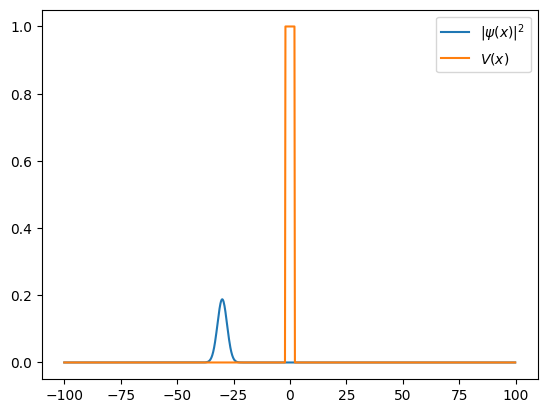

In [109]:
plt.plot(grid.x,np.abs(wavefunc)**2,label = r"$|\psi(x)|^2$")
plt.plot(grid.x,potential/ np.max(np.abs(potential)),label = r"$V(x)$")
plt.legend()

In [110]:
solver = TDSESolver(grid,dt,potential,m=m,hbar= hbar)
solution = solver.run(wavefunc,Nt)
obser = Observerables(grid,potential)
T, R, KE, PE, Norm, =obser.track_all(solution,grid,barrier_left,barrier_right, hbar)
H = np.add(KE,PE)


enlapsed_us of run: 0.91s 
enlapsed_us of track_all: 0.94s 


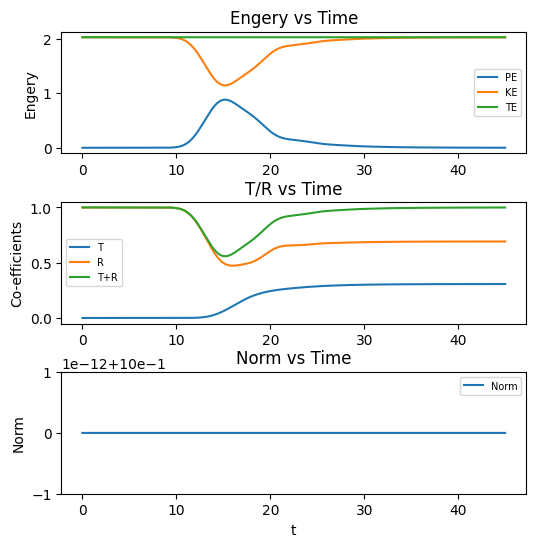

In [111]:
fig = plt.figure(figsize=(6,6),dpi=100)
gs = GridSpec(3,1)
legend_font_size = 7
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[2,0])
plt.subplots_adjust(wspace=0.1,hspace=0.4)
ax0.set_title("Engery vs Time")
ax1.set_title("T/R vs Time")
ax2.set_title("Norm vs Time")

ax2.set_xlabel("t")

ax0.set_ylabel("Engery")
ax1.set_ylabel("Co-efficients")
ax2.set_ylabel("Norm")


ax0.plot(t,PE,label = "PE")
ax0.plot(t,KE,label = "KE")
ax0.plot(t,H, label = "TE")
ax0.legend(fontsize = legend_font_size)

ax1.plot(t,T,label = "T")
ax1.plot(t,R,label = "R")
ax1.plot(t,np.add(T,R),label = "T+R")
ax1.legend(fontsize = legend_font_size)

ax2.plot(t,Norm,label = "Norm")
ax2.legend(fontsize = legend_font_size)

In [118]:
class Plo_t:
    def __init__(self, grid, solution, potential, time, T, R, KE, PE, Norm):
        self.grid = grid
        self.solution = solution
        self.potential = potential
        self.time = time
        self.T = T
        self.R = R
        self.KE = KE
        self.PE = PE
        self.Norm = Norm
        self.H = np.add(KE, PE)

    @timer_dec
    def animate_density_video(self, outname, out_codec, fps=30):

        fig = plt.figure(figsize=(12, 8), dpi=100)
        gs = GridSpec(3, 2)

        ax0 = fig.add_subplot(gs[0, 0])  # Density
        ax1 = fig.add_subplot(gs[0, 1])  # Energy
        ax2 = fig.add_subplot(gs[1, 0])  # Real
        ax3 = fig.add_subplot(gs[1, 1])  # T/R
        ax4 = fig.add_subplot(gs[2, 0])  # Imag
        ax5 = fig.add_subplot(gs[2, 1])  # Norm

        plt.subplots_adjust(wspace=0.3, hspace=0.4)

        x = self.grid.x

        # =========================
        # Normalize potential
        # =========================

        pot_norm = self.potential / np.max(np.abs(self.potential))

        # =========================
        # Precompute global data
        # =========================

        density = np.abs(self.solution)**2
        real_vals = self.solution.real
        imag_vals = self.solution.imag

        # --- Helper for combined limits ---
        def combined_limits(data, pot_norm):
            V_scaled = pot_norm 
            y_min = min(data.min(), V_scaled.min())
            y_max = max(data.max(), V_scaled.max())
            return y_min, y_max, V_scaled

        # Compute limits + scaled potentials
        den_y_min, den_y_max, V_den = combined_limits(density, pot_norm)
        real_y_min, real_y_max, V_real = combined_limits(real_vals, pot_norm)
        imag_y_min, imag_y_max, V_imag = combined_limits(imag_vals, pot_norm)

        # =========================
        # Density
        # =========================

        ax0.set_xlim(x.min(), x.max())
        ax0.set_ylim(den_y_min, den_y_max)
        (den,) = ax0.plot([], [], label="|ψ|²")
        ax0.plot(x, V_den, "--", label="V(x)")

        # =========================
        # Energy
        # =========================

        ax1.set_xlim(self.time.min(), self.time.max())
        e_max = max(np.max(self.PE), np.max(self.KE), np.max(self.H))
        e_min = min(np.min(self.PE), np.min(self.KE), np.min(self.H))
        ax1.set_ylim(e_min, e_max+ 0.5)

        (KE_line,) = ax1.plot([], [], label="KE")
        (PE_line,) = ax1.plot([], [], label="PE")
        (H_line,)  = ax1.plot([], [], label="Total")

        # =========================
        # Real
        # =========================
        ax2.set_xlim(x.min(), x.max())
        ax2.set_ylim(real_y_min, real_y_max)
        (real,) = ax2.plot([], [], label="Re(ψ)")
        ax2.plot(x, V_real, "--", label="V(x)")

        # =========================
        # T / R
        # =========================

        ax3.set_xlim(self.time.min(), self.time.max())
        ax3.set_ylim(0, 1.2)
        (T_line,) = ax3.plot([], [], label="T")
        (R_line,) = ax3.plot([], [], label="R")
        (TR_line,) = ax3.plot([], [], label="T+R")

        # =========================
        # Imag
        # =========================

        ax4.set_xlim(x.min(), x.max())
        ax4.set_ylim(imag_y_min, imag_y_max)
        (imag,) = ax4.plot([], [], label="Im(ψ)")
        ax4.plot(x, V_imag, "--", label="V(x)")

        # =========================
        # Norm
        # =========================

        ax5.set_xlim(self.time.min(), self.time.max())
        ax5.set_ylim(0.95, 1.05)
        (Norm_line,) = ax5.plot([], [], label="Norm")

        # =========================
        # Style
        # =========================

        for ax in [ax0, ax1, ax2, ax3, ax4, ax5]:
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)

        writer = FFMpegFileWriter(fps=fps, codec=out_codec)

        time_vals = []
        T_vals, R_vals, TR_vals = [], [], []
        KE_vals, PE_vals, H_vals = [], [], []
        Norm_vals = []

        with writer.saving(fig, outname, dpi=100):
            for i in range(0, len(self.solution), 100):

                psi = self.solution[i]

                # --- Wave ---
                den.set_data(x, np.abs(psi)**2)
                real.set_data(x, psi.real)
                imag.set_data(x, psi.imag)

                # --- Time ---
                t_val = self.time[i]
                time_vals.append(t_val)

                T_vals.append(self.T[i])
                R_vals.append(self.R[i])
                TR_vals.append(self.T[i] + self.R[i])

                KE_vals.append(self.KE[i])
                PE_vals.append(self.PE[i])
                H_vals.append(self.H[i])

                Norm_vals.append(self.Norm[i])

                # --- Update ---
                T_line.set_data(time_vals, T_vals)
                R_line.set_data(time_vals, R_vals)
                TR_line.set_data(time_vals, TR_vals)

                KE_line.set_data(time_vals, KE_vals)
                PE_line.set_data(time_vals, PE_vals)
                H_line.set_data(time_vals, H_vals)

                Norm_line.set_data(time_vals, Norm_vals)

                # --- Titles ---
                ax0.set_title(f"Density (t={t_val:.2e})")
                ax1.set_title("Energy")
                ax2.set_title("Real")
                ax3.set_title("Transmission / Reflection")
                ax4.set_title("Imag")
                ax5.set_title("Norm")

                writer.grab_frame()

        plt.close(fig)

In [119]:
file_name = "results/finite-barrier/out.gif"
plotting = Plo_t(grid,solution,potential,t,T,R,KE,PE,Norm)
plotting.animate_density_video(file_name,"gif")

enlapsed_us of animate_density_video: 31.38s 
